# Drogued drifter in effective currents

Running the drogued drifter model (from notebook 03) in effective current
fields that combine Eulerian currents with depth-dependent Stokes drift
profiles (from notebook 06). This is the first simulation using the full
physics pipeline: Eulerian + Stokes at each depth level, sampled at the
buoy and drogue depths by the drifter kernel.

## Imports

In [ ]:
import shutil
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from parcels import FieldSet, Particle, ParticleFile, ParticleSet, StatusCode, Variable
from parcels._core.statuscodes import FieldOutOfBoundError
from parcels.kernels import AdvectionRK4

from drogued_drifters.drifter import DroguedDrifter

## Parameters

In [ ]:
LON_MIN = 9.5
LON_MAX = 11.5
LAT_MIN = 54.0
LAT_MAX = 55.5
TIME_START = "2023-04-24"
TIME_END = "2023-04-27"
N_PARTICLES = 20
LON_BOUNDS = [10.0, 11.0]
LAT_BOUNDS = [54.3, 54.6]
RANDOM_SEED = 42
DROGUE_DEPTH = 3.0
DT = 300.0
RUNTIME_HOURS = 48
CMEMS_DIR = "data/cmems"

## Build effective current field

Reproducing the pipeline from notebook 06: load CMEMS Eulerian currents
and wave partitions, compute the Stokes drift profile at each depth
level, interpolate onto the physics grid, and add them to get the
effective current.

In [ ]:
LON = slice(LON_MIN, LON_MAX)
LAT = slice(LAT_MIN, LAT_MAX)
TIME = slice(TIME_START, TIME_END)

ds_phy = xr.open_dataset(CMEMS_DIR + "/cmems_mod_bal_phy_anfc_PT1H-i.nc").sel(
    longitude=LON, latitude=LAT, time=TIME,
).load()

ds_phy

In [ ]:
WAVE_VARS = [
    "VHM0_WW", "VTM01_WW", "VMDR_WW",
    "VHM0_SW1", "VTM01_SW1", "VMDR_SW1",
    "VHM0_SW2", "VTM01_SW2", "VMDR_SW2",
]

ds_wav = xr.open_dataset(CMEMS_DIR + "/cmems_mod_bal_wav_anfc_PT1H-i.nc").sel(
    longitude=LON, latitude=LAT, time=TIME,
)[WAVE_VARS].load()

ds_wav

### Stokes drift profiles from wave partitions

Deep-water monochromatic approximation per partition, evaluated at each
Eulerian depth level. See notebook 06 for details.

In [5]:
g = 9.81
# Include z=0 in the depth levels for Stokes computation
depth_levels = np.concatenate([[0.0], ds_phy.depth.values])

PARTITIONS = [
    ("VHM0_WW", "VTM01_WW", "VMDR_WW"),
    ("VHM0_SW1", "VTM01_SW1", "VMDR_SW1"),
    ("VHM0_SW2", "VTM01_SW2", "VMDR_SW2"),
]

u_stokes = xr.DataArray(
    np.zeros((len(ds_wav.time), len(depth_levels), len(ds_wav.latitude), len(ds_wav.longitude))),
    dims=["time", "depth", "latitude", "longitude"],
    coords={"time": ds_wav.time, "depth": depth_levels,
            "latitude": ds_wav.latitude, "longitude": ds_wav.longitude},
)
v_stokes = u_stokes.copy()

for hs_var, t_var, dir_var in PARTITIONS:
    hs = ds_wav[hs_var]
    T = ds_wav[t_var]
    dir_from = ds_wav[dir_var]

    valid = hs > 0.01
    A = hs / 2
    sigma = 2 * np.pi / T
    k = sigma**2 / g
    theta = np.deg2rad(270.0 - dir_from)
    stokes_surf = A**2 * sigma * k

    for i, z in enumerate(depth_levels):
        decay = np.exp(-2 * k * float(z))
        u_stokes[dict(depth=i)] += (stokes_surf * decay * np.cos(theta)).where(valid, 0.0).fillna(0.0)
        v_stokes[dict(depth=i)] += (stokes_surf * decay * np.sin(theta)).where(valid, 0.0).fillna(0.0)

### Interpolate Stokes onto the physics grid and build effective current

In [6]:
ds_stokes = xr.Dataset({"u_stokes": u_stokes, "v_stokes": v_stokes})

ds_stokes_phys = ds_stokes.interp(
    longitude=ds_phy.longitude,
    latitude=ds_phy.latitude,
    method="linear",
).fillna(0.0)

# Add z=0 layer to Eulerian by copying shallowest level
ds_phy_z0 = ds_phy.isel(depth=0).assign_coords(depth=0.0)
ds_phy_ext = xr.concat([ds_phy_z0, ds_phy], dim="depth")

# Apply land mask from Eulerian data
land_mask = ds_phy_ext["uo"].isnull()
ds_stokes_phys["u_stokes"] = ds_stokes_phys["u_stokes"].where(~land_mask)
ds_stokes_phys["v_stokes"] = ds_stokes_phys["v_stokes"].where(~land_mask)

# Effective current = Eulerian + Stokes (both now have z=0 level)
ds_eff = xr.Dataset({
    "U": (ds_phy_ext["uo"] + ds_stokes_phys["u_stokes"]).fillna(0.0),
    "V": (ds_phy_ext["vo"] + ds_stokes_phys["v_stokes"]).fillna(0.0),
})
ds_eff

<xarray.Dataset> Size: 60MB
Dimensions:    (depth: 6, latitude: 90, longitude: 72, time: 96)
Coordinates:
  * depth      (depth) float64 48B 0.0 0.5016 1.516 2.548 3.602 4.684
  * latitude   (latitude) float32 360B 54.01 54.02 54.04 ... 55.46 55.47 55.49
  * longitude  (longitude) float32 288B 9.514 9.542 9.569 ... 11.43 11.46 11.49
  * time       (time) datetime64[ns] 768B 2023-04-24 ... 2023-04-27T23:00:00
Data variables:
    U          (time, latitude, longitude, depth) float64 30MB 0.0 0.0 ... 0.0
    V          (time, latitude, longitude, depth) float64 30MB 0.0 0.0 ... 0.0

### Build FieldSet

Add SGRID metadata and build the Parcels FieldSet. The effective current
already includes a z=0 layer with the correct Stokes drift (computed at
z=0, not copied from 0.5 m).

In [7]:
# SGRID metadata for Parcels
ds_eff["grid"] = xr.DataArray(
    data=0,
    attrs={
        "cf_role": "grid_topology",
        "topology_dimension": 2,
        "node_dimensions": "longitude latitude",
        "face_dimensions": (
            "longitude:longitude (padding: none) "
            "latitude:latitude (padding: none)"
        ),
        "vertical_dimensions": "depth:depth (padding: none)",
        "node_coordinates": "longitude latitude",
    },
)

fieldset = FieldSet.from_sgrid_conventions(ds_eff, mesh="spherical")
fieldset.add_constant("drogue_depth", DROGUE_DEPTH)

## Drifter kernel

At each Parcels timestep, build a `sample_uv(z)` closure that queries
the FieldSet at arbitrary depth for all particles. Pass this sampler to
`DroguedDrifter.get_final_drift_batch`, which solves the full equations
of motion to steady state. During integration, the ODE solver queries
velocities at z=0 (buoy) and the current effective depth z_eff(theta)
(drogue), so the drogue depth tracks the pole tilt.

Because the FieldSet uses `mesh="spherical"`, Parcels returns velocities
in deg/s. The `sample_uv` closure converts to m/s (what the Cartesian
drifter model expects). The output drift velocity (m/s) is converted
back to deg/s before updating dlon/dlat.

Trajectories are stored in a Python dict (Parcels v4 zarr writer has
a known bug with custom kernels).

In [ ]:
DrifterParticle = Particle.add_variable(Variable("z_eff", dtype=np.float64, initial=0.0))

dd = DroguedDrifter()
_warm_state = {}

drifter_trajectory = {"lon": [], "lat": [], "time": []}

_DEG2M = 1852.0 * 60.0  # meters per degree of latitude


def DroguedDrifterKernel(particles, fieldset):
    """Advect particles using the full velocity profile via sample_uv."""
    n = len(np.asarray(particles.lon))
    dt = np.asarray(particles.dt)
    lon_arr = np.asarray(particles.lon)
    lat_arr = np.asarray(particles.lat)
    time_arr = np.asarray(particles.time)

    cos_lat = np.cos(np.deg2rad(lat_arr))
    deg2m_lon = _DEG2M * cos_lat

    def sample_uv(z):
        """Query the FieldSet at arbitrary depth z for all particles (returns m/s)."""
        z_arr = np.broadcast_to(np.asarray(z, dtype=float), n)
        try:
            u, v = fieldset.UV[
                particles.time, z_arr, particles.lat, particles.lon, particles
            ]
        except FieldOutOfBoundError:
            particles.state = StatusCode.Delete
            return np.zeros(n), np.zeros(n)
        u, v = np.asarray(u), np.asarray(v)
        # Convert deg/s to m/s
        u_ms = u * deg2m_lon
        v_ms = v * _DEG2M
        return u_ms, v_ms

    y0_warm = _warm_state.get("Y") if _warm_state.get("n") == n else None
    xd_drift_ms, yd_drift_ms, theta_final, Y_final = dd.get_final_drift_batch(
        sample_uv=sample_uv, y0=y0_warm,
    )
    _warm_state["Y"] = Y_final
    _warm_state["n"] = n
    z_eff = -dd.l * np.cos(theta_final)

    # m/s -> deg/s (back to Parcels spherical convention)
    xd_drift = xd_drift_ms / deg2m_lon
    yd_drift = yd_drift_ms / _DEG2M

    particles.dlon += xd_drift * dt
    particles.dlat += yd_drift * dt
    particles.z_eff = z_eff

    drifter_trajectory["lon"].append(lon_arr.copy())
    drifter_trajectory["lat"].append(lat_arr.copy())
    drifter_trajectory["time"].append(time_arr.copy())


def DeleteOOB(particles, fieldset):
    """Convert out-of-bounds errors to Delete status."""
    state = np.asarray(particles.state)
    oob = (state == StatusCode.ErrorOutOfBounds) | (state == StatusCode.ErrorThroughSurface)
    if np.any(oob):
        particles.state = np.where(oob, StatusCode.Delete, state)

## Release particles

20 random positions in the southern Kiel Bight.

In [ ]:
rng = np.random.default_rng(RANDOM_SEED)
release_lons = rng.uniform(*LON_BOUNDS, N_PARTICLES)
release_lats = rng.uniform(*LAT_BOUNDS, N_PARTICLES)

## Run simulations

Three runs from the same initial positions in the effective current field:
1. Drogued drifter (custom kernel, forward Euler)
2. Surface point particle (AdvectionRK4 at z=0)
3. 3 m point particle (AdvectionRK4 at z=3 m)

In [10]:
RUNTIME = RUNTIME_HOURS * 3600
OUTPUTDT = 3600.0
SHALLOWEST_DEPTH = float(ds_eff.depth.values[0])

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
# Drogued drifter run
pset_drifter = ParticleSet(
    fieldset=fieldset,
    pclass=DrifterParticle,
    lon=release_lons.tolist(),
    lat=release_lats.tolist(),
    z=[SHALLOWEST_DEPTH] * N_PARTICLES,
)
pset_drifter.execute(
    kernels=[DroguedDrifterKernel, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    verbose_progress=False,
)

  0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 0.0:   0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000:   0%|          | 0/172800.0 [00:19<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000: 100%|██████████| 172800.0/172800.0 [00:19<00:00, 9090.93it/s]

Integration time: 2023-04-24T00:00:00.000000000: 100%|██████████| 172800.0/172800.0 [00:19<00:00, 9090.78it/s]

In [12]:
# Surface point particle run
surface_store = str(OUTPUT_DIR / "eff_surface.zarr")
shutil.rmtree(surface_store, ignore_errors=True)

pset_surface = ParticleSet(
    fieldset=fieldset,
    pclass=Particle,
    lon=release_lons.tolist(),
    lat=release_lats.tolist(),
    z=[SHALLOWEST_DEPTH] * N_PARTICLES,
)
pset_surface.execute(
    kernels=[AdvectionRK4, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    output_file=ParticleFile(store=surface_store, outputdt=OUTPUTDT),
    verbose_progress=False,
)

INFO: Output files are stored in /Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/output/eff_surface.zarr


  0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 0.0:   0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000:   0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000:   0%|          | 0.0/172800.0 [00:00<?, ?it/s]

...

Integration time: 2023-04-25T21:00:00.000000000:  94%|█████████▍| 162000.0/172800.0 [00:02<00:00, 75925.45it/s]

Integration time: 2023-04-25T21:00:00.000000000:  96%|█████████▌| 165600.0/172800.0 [00:02<00:00, 75193.55it/s]

Integration time: 2023-04-25T22:00:00.000000000:  96%|█████████▌| 165600.0/172800.0 [00:02<00:00, 75193.55it/s]

Integration time: 2023-04-25T23:00:00.000000000:  98%|█████████▊| 169200.0/172800.0 [00:02<00:00, 75193.55it/s]

Integration time: 2023-04-25T23:00:00.000000000: 100%|██████████| 172800.0/172800.0 [00:02<00:00, 74098.82it/s]

In [13]:
# 3m point particle run
DROGUE_DEPTH_LEVEL = float(ds_eff.depth.sel(depth=DROGUE_DEPTH, method="nearest"))

drogue_store = str(OUTPUT_DIR / "eff_drogue.zarr")
shutil.rmtree(drogue_store, ignore_errors=True)

pset_drogue = ParticleSet(
    fieldset=fieldset,
    pclass=Particle,
    lon=release_lons.tolist(),
    lat=release_lats.tolist(),
    z=[DROGUE_DEPTH_LEVEL] * N_PARTICLES,
)
pset_drogue.execute(
    kernels=[AdvectionRK4, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    output_file=ParticleFile(store=drogue_store, outputdt=OUTPUTDT),
    verbose_progress=False,
)

INFO: Output files are stored in /Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/output/eff_drogue.zarr


  0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 0.0:   0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000:   0%|          | 0/172800.0 [00:00<?, ?it/s]

Integration time: 2023-04-24T00:00:00.000000000:   0%|          | 0.0/172800.0 [00:00<?, ?it/s]

...

Integration time: 2023-04-25T21:00:00.000000000:  94%|█████████▍| 162000.0/172800.0 [00:02<00:00, 74196.19it/s]

Integration time: 2023-04-25T21:00:00.000000000:  96%|█████████▌| 165600.0/172800.0 [00:02<00:00, 73714.03it/s]

Integration time: 2023-04-25T22:00:00.000000000:  96%|█████████▌| 165600.0/172800.0 [00:02<00:00, 73714.03it/s]

Integration time: 2023-04-25T23:00:00.000000000:  98%|█████████▊| 169200.0/172800.0 [00:02<00:00, 73714.03it/s]

Integration time: 2023-04-25T23:00:00.000000000: 100%|██████████| 172800.0/172800.0 [00:02<00:00, 70030.85it/s]

## Plot trajectories

Surface point particles (red), 3 m point particles (green), drogued
drifters (blue, dashed).

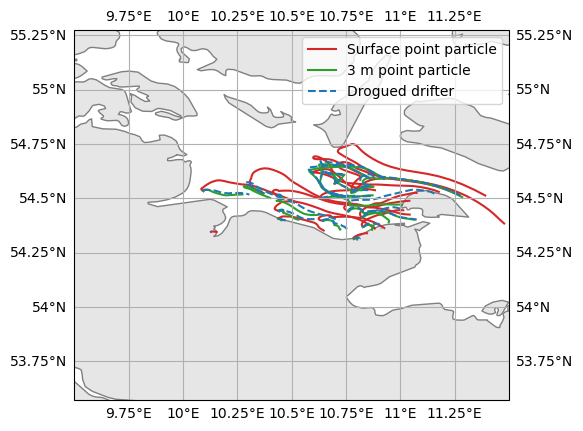

In [14]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

# Surface point particles
ds_surface = xr.open_zarr(surface_store)
for i in range(ds_surface.sizes["trajectory"]):
    lon_i = ds_surface.lon.values[i, :]
    lat_i = ds_surface.lat.values[i, :]
    valid = np.isfinite(lon_i)
    ax.plot(lon_i[valid], lat_i[valid], color="tab:red",
            label="Surface point particle" if i == 0 else None)

# 3m point particles
ds_drogue = xr.open_zarr(drogue_store)
for i in range(ds_drogue.sizes["trajectory"]):
    lon_i = ds_drogue.lon.values[i, :]
    lat_i = ds_drogue.lat.values[i, :]
    valid = np.isfinite(lon_i)
    ax.plot(lon_i[valid], lat_i[valid], color="tab:green",
            label="3 m point particle" if i == 0 else None)

# Drogued drifters from trajectory dict
if drifter_trajectory["lon"]:
    n0 = len(drifter_trajectory["lon"][0])
    full_steps = [i for i, arr in enumerate(drifter_trajectory["lon"]) if len(arr) == n0]
    if full_steps:
        d_lon = np.array([drifter_trajectory["lon"][i] for i in full_steps])
        d_lat = np.array([drifter_trajectory["lat"][i] for i in full_steps])
        for i in range(n0):
            ax.plot(d_lon[:, i], d_lat[:, i], color="tab:blue", ls="--",
                    label="Drogued drifter" if i == 0 else None)

land = cfeature.NaturalEarthFeature("physical", "land", "10m",
                                     facecolor="0.9", edgecolor="0.5")
ax.add_feature(land)
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN - 0.2, LAT_MAX])
ax.gridlines(draw_labels=True)
ax.legend()
plt.show()